<a href="https://colab.research.google.com/github/aman-5137/half_plasma/blob/main/LOgistic_Regression_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
# as_frame : shows us the exactly how the data looks
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [11]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [12]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
iris.data
# [sepal width, sepal height, petal width, petal height]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [15]:
df = iris.frame.copy()
df.head()
# This methods provides us the target value

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [18]:
df.target.unique()
# So the target is 0, 1, 2 (means the tree flower types)

array([0, 1, 2])

In [19]:
# To change the column names we can
df.columns = ['sepal_width', 'sepal_height', 'petal_width', 'petal_height', 'target']
df.head()

,sepal_width,sepal_height,petal_width,petal_height,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
# To find the names of the target values
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
# To change the target numbers to names of the flowers
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal_width,sepal_height,petal_width,petal_height,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [26]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [31]:
# Now we can drop the cloumn 'target' to save space by
df = df.drop(columns="target")
df.head()


,sepal_width,sepal_height,petal_width,petal_height,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [32]:
# To check how many records are their of each flower
df.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


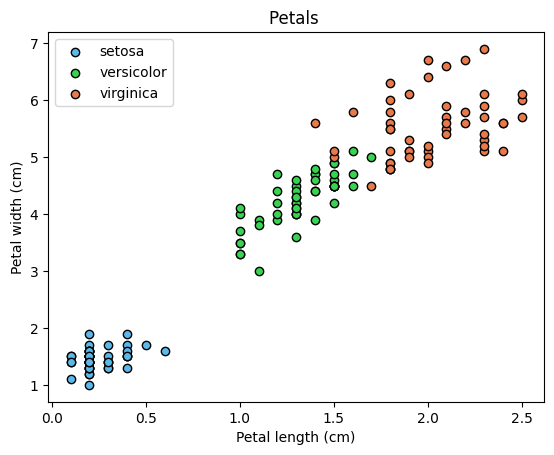

In [40]:
import matplotlib.pyplot as plt
colors = {'setosa': '#5BB8E8', 'versicolor': '#39D353', 'virginica': '#E8794B'}
for name, group in df.groupby('species'):
  plt.scatter(group.petal_height, group.petal_width,
              color=colors[name], edgecolor='k', label=name)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Petals ")
plt.legend()
plt.show()


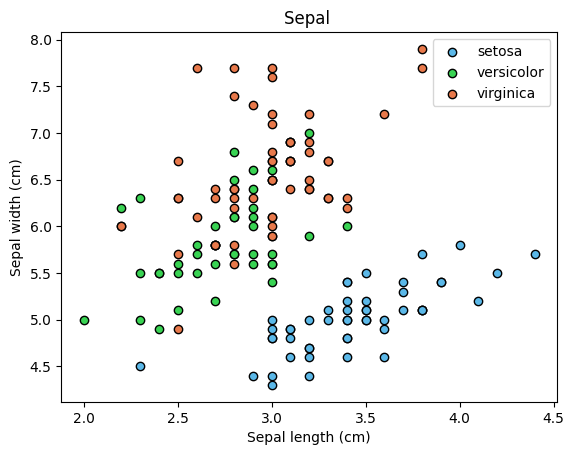

In [41]:
import matplotlib.pyplot as plt
colors = {'setosa': '#5BB8E8', 'versicolor': '#39D353', 'virginica': '#E8794B'}
for name, group in df.groupby('species'):
  plt.scatter(group.sepal_height, group.sepal_width,
              color=colors[name], edgecolor='k', label=name)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Sepal ")
plt.legend()
plt.show()


In [42]:
feature = ['sepal_width', 'sepal_height', 'petal_width', 'petal_height']
X = df[feature]
y = df.species

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X train shape:",X_train.shape)
print("y train shape:",X_test.shape)
print("X test shape:",y_train.shape)
print("y train shape:",y_test.shape)

X train shape: (120, 4)
y train shape: (30, 4)
X test shape: (120,)
y train shape: (30,)


In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [50]:
model.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [51]:
model.predict(X_test)

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [54]:
import pandas as pd
y_predicted = model.predict(X_test)
compare = pd.DataFrame({'actual':y_test.values, 'predicted':y_predicted})

compare.head(10)

,actual,predicted
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


In [56]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_predicted, labels = model.classes_)

# So in our model we did not get any mistakes as the diagonal elements are the truth and rest are zeros


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [67]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predicted ))
# Our model works perfectly, without any wrong predictions so the reports are 100% correct

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [66]:
new_flower = pd.DataFrame([{'sepal_width': 5.1, 'sepal_height': 3.5,'petal_width': 1.4, 'petal_height': 0.2}])
# 'sepal_width', 'sepal_height', 'petal_width', 'petal_height'
print("Predicted species:", model.predict(new_flower)[0])
# Predicted species: setosa

# So we predicted a new flower

Predicted species: setosa
